In [22]:
import numpy as np
import scipy
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['text.usetex'] = True

import csv
import func

In [3]:
eigs = np.loadtxt('eig_train_small.csv', delimiter=',')
m_train = lambda ls: func.m_C(eigs, ls)

In [4]:
sig = lambda x: np.tanh(2*x)
g, g_prime, coeffs = func.gg(sig)

In [5]:
def mmse_qw(qw_init, v, Pv, alpha, gamma, Delta, m): 
    # v: set of values, Pv: masses at v, m: overlap function
    qw = np.copy(qw_init)
    for i in range(500):
        qw_old = qw.copy()
        mmse = g(1) - np.sum(Pv * v**2 * g(qw))
        rw = alpha/gamma * v**2 * g_prime(qw)/(Delta + mmse) 
        qw = m(rw) # 
        if np.max(np.abs(qw - qw_old))< 1e-9:
            break
    return mmse, qw

### Theory

In [6]:
gamma = 0.5
Delta = 0.1
n_point = 201
qw_init = np.array([1]*n_point)
v = np.linspace(-4, 4, n_point)
Pv = np.exp(-v**2/2)/np.sqrt(2*np.pi)
Pv /= np.sum(Pv)

# theory
alphas = np.linspace(0, 3, 201)
mmses = [mmse_qw(qw_init, v, Pv, alpha, gamma, Delta, m_train)[0] for alpha in alphas]

In [26]:
mmse_qw(qw_init, v, Pv, 1, gamma, Delta, m_train)[0]

np.float64(0.02535567794065767)

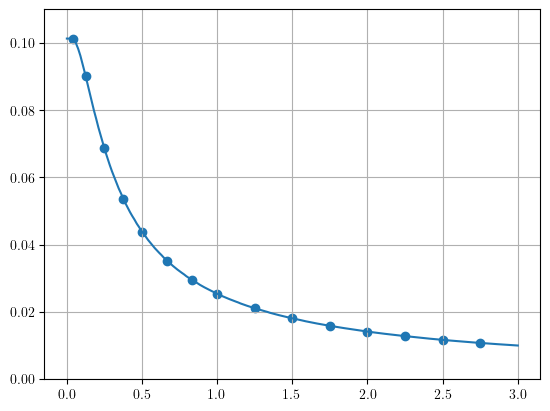

In [25]:
alphas_ = [0.04, 0.125, 0.25, 0.375, 0.5, 2/3, 5/6, 1, 1.25, 1.5, 1.75, 2, 2.25, 2.5, 2.75]
# alphas_ = [0.15, 0.3, 0.45, 0.6, 0.75, 1, 1.25, 1.5, 1.75, 2, 2.25, 2.5, 2.75]
mmses_ = [mmse_qw(qw_init, v, Pv, alpha, gamma, Delta, m_train)[0] for alpha in alphas_]
plt.scatter(alphas_, mmses_)

plt.plot(alphas, mmses)
plt.grid()
plt.ylim(0, 0.11)
plt.show()